In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

In [25]:
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

In [26]:
print(df1.columns)
print(df2.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [27]:
df1["Region.1"] = np.nan
df1["longitude"] = np.nan
df1["latitude"] = np.nan

df2["Area"] = np.nan

In [28]:
df = pd.concat([df1, df2], ignore_index=True)

In [29]:
print(df.shape)
df.head()

(1035, 10)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Region.1,longitude,latitude
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural,NaN,NaN,NaN
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural,NaN,NaN,NaN
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural,NaN,NaN,NaN
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural,NaN,NaN,NaN
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural,NaN,NaN,NaN


In [30]:
df = df.dropna(subset=["Estimated Unemployment Rate (%)", "Date", "Region"])

In [31]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [32]:
print(df.shape)
print(df.isnull().sum())
df.head()

(1007, 10)
Region                                       0
Date                                         0
Frequency                                    0
Estimated Unemployment Rate (%)              0
Estimated Employed                           0
Estimated Labour Participation Rate (%)      0
Area                                       267
Region.1                                   740
longitude                                  740
latitude                                   740
dtype: int64


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Region.1,longitude,latitude
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,NaN,NaN,NaN
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,NaN,NaN,NaN
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,NaN,NaN,NaN
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,NaN,NaN,NaN
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,NaN,NaN,NaN


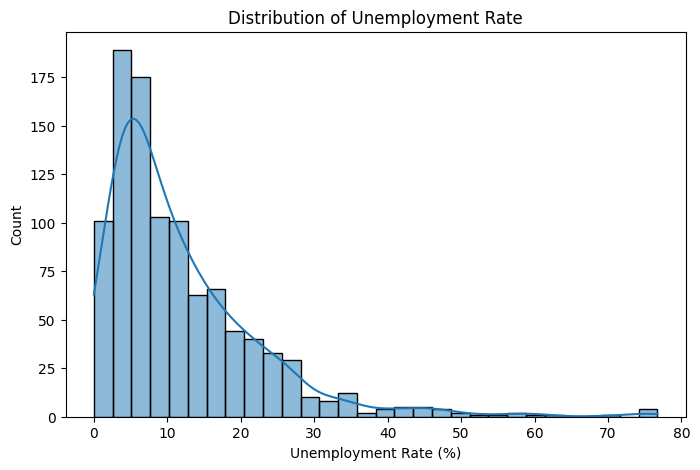

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated Unemployment Rate (%)"], bins=30, kde=True)
plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Count")
plt.show()

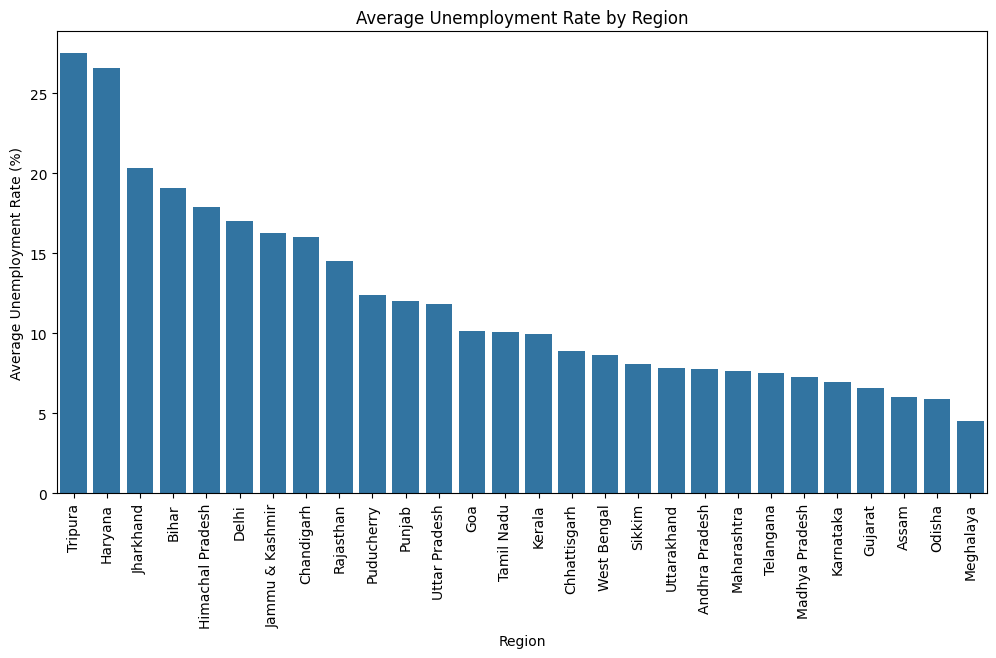

In [34]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=region_avg.index, y=region_avg.values)
plt.xticks(rotation=90)
plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

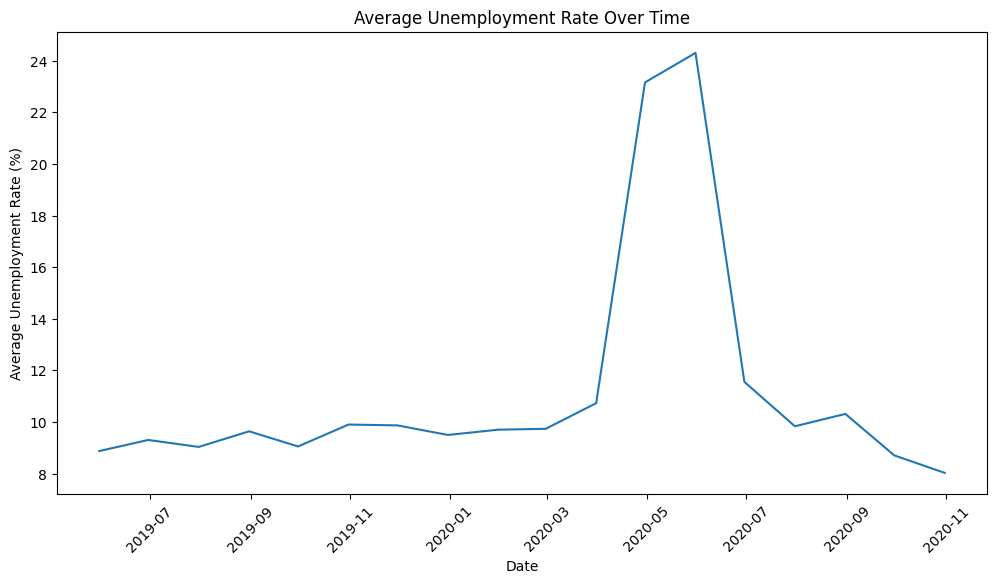

In [35]:
date_avg = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(12,6))
plt.plot(date_avg.index, date_avg.values)
plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

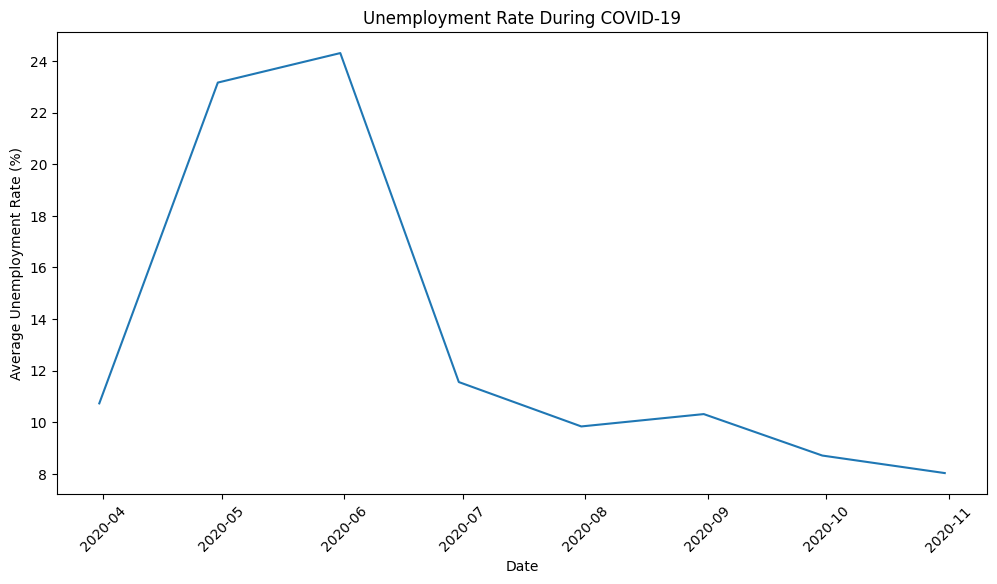

In [36]:
covid_data = df[df["Date"] >= "2020-03-01"]
covid_avg = covid_data.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(12,6))
plt.plot(covid_avg.index, covid_avg.values)
plt.title("Unemployment Rate During COVID-19")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

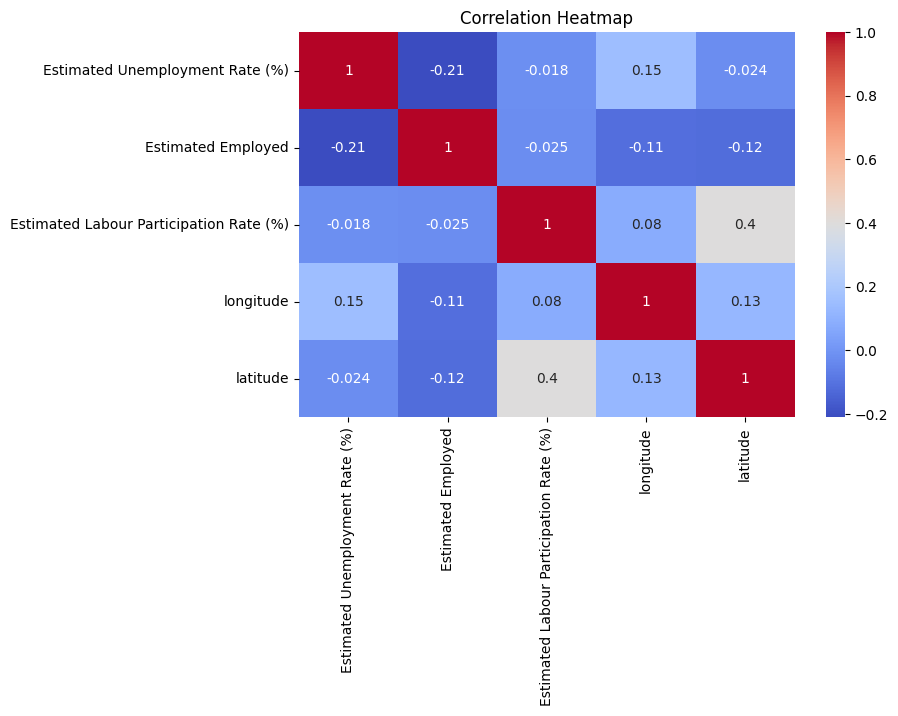

In [37]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

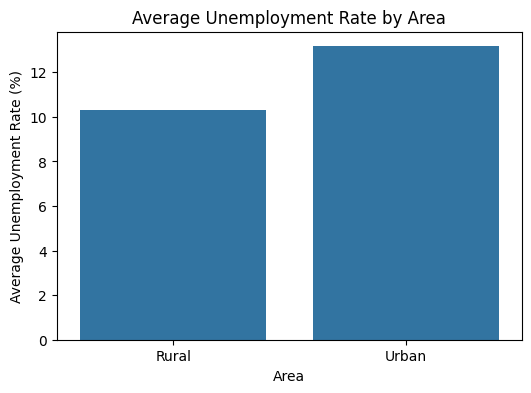

In [38]:
area_df = df.dropna(subset=["Area"])

area_analysis = area_df.groupby("Area")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=area_analysis.index, y=area_analysis.values)
plt.title("Average Unemployment Rate by Area")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()